In [1]:
# Basic
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# For prediction
from tensorflow.keras.preprocessing import image

In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)

dataset_path = "SmallImageDS"

train_data = datagen.flow_from_directory(
    "SmallImageDS",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "SmallImageDS",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 229 images belonging to 6 classes.
Found 56 images belonging to 6 classes.


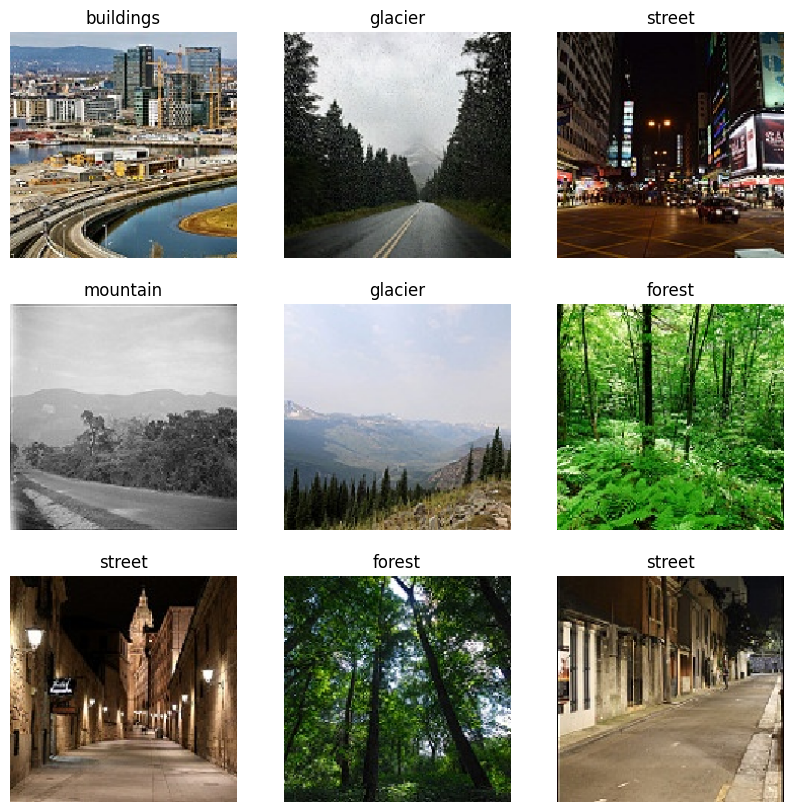

In [3]:
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis('off')

plt.show()

In [4]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.1834 - loss: 3.0378 - val_accuracy: 0.1786 - val_loss: 1.7651
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.2402 - loss: 1.6903 - val_accuracy: 0.4464 - val_loss: 1.5152
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.4323 - loss: 1.4591 - val_accuracy: 0.4286 - val_loss: 1.4542
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.5284 - loss: 1.2610 - val_accuracy: 0.5179 - val_loss: 1.2153
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.5677 - loss: 1.1995 - val_accuracy: 0.4821 - val_loss: 1.2651
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - accuracy: 0.6288 - loss: 0.9850 - val_accuracy: 0.5893 - val_loss: 1.1863
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.6987 - loss: 0.7894 - val_accuracy: 0.6071 - val_loss: 1.0834
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.7118 - loss: 0.6624 - val_accuracy: 0.4643 - val_loss:

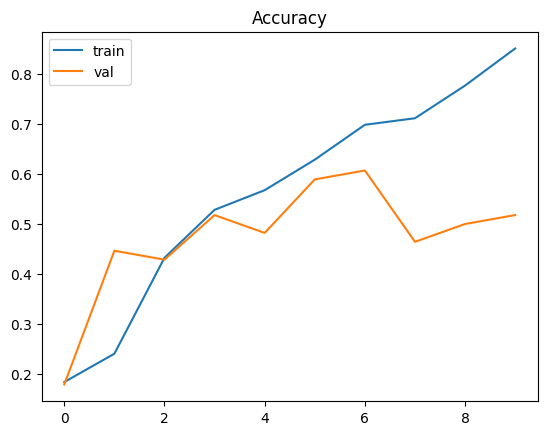

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


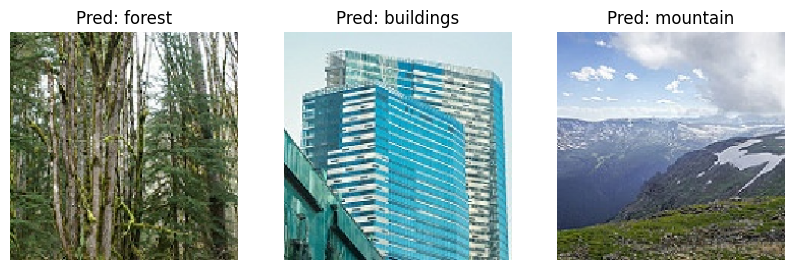

In [12]:
all_images = []

for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    if os.path.isdir(folder):
        for img in os.listdir(folder):
            all_images.append(os.path.join(folder, img))

# pick 3 random images
random_images = random.sample(all_images, 3)

class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,5))

for i, img_path in enumerate(random_images):
    
    # load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    # show image
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')

plt.show()